# Experiment 5: P(Lexical Match | Token Rank)

This notebook analyzes the probability that a token retrieved at rank k is a **lexical match** (exact same token ID) with the query token.

This is complementary to Experiment 4 which measured P(Gold | Rank) - whether retrieved tokens come from relevant documents.

**Approach:**
- Sample a subset of queries and documents (to fit in memory)
- Encode with token ID tracking (using the tokenizer)
- Compute pairwise token similarities
- For each query token, rank document tokens and check lexical match at each rank

## Setup

In [2]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Dict, List, Tuple, Set
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Add project root to path for imports
project_root = Path.cwd()
if str(project_root) not in sys.path:
    print(f"Adding project root to path: {project_root}")
    sys.path.insert(0, str(project_root))

from pylate import models

# Reuse helpers from eval script
from eval_model_irds_v2 import (
    load_dataset,
    sanitize_dataset_name,
    sanitize_model_name,
    resolve_query_length,
    get_torch_dtype,
    QUERY_LEN,
)

In [3]:
documents, queries, qrels = load_dataset("beir/nfcorpus/test", lowercase=False)

Loading documents: 0docs [00:00, ?docs/s]

Loading queries: 0queries [00:00, ?queries/s]

Loading qrels: 0qrels [00:00, ?qrels/s]

In [4]:
len(documents)

3633

## Configuration

In [ ]:
# Models: list of (model_path, model_display_name) tuples
MODELS = [
    ("output/experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k/checkpoint-50000", "XTR (bug)"),
    ("output/experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_bugfix/checkpoint-50000", "XTR (bugfix)"),
    ("output/experiment_1_contrastive_colbert_bs196_50k/checkpoint-50000", "ColBERT"),
    ("lightonai/GTE-ModernColBERT-v1", "GTE-ModernColBERT"),
    ("robro612/xtr-base-en-pylate", "Google-XTR"),
]

# Datasets: list of dataset IDs
DATASET_IDS = [
    "beir/nfcorpus/test",
    "beir/fiqa/test",
    "beir/trec-covid",
    "beir/nq",
]

# Sampling
NUM_QUERIES = None          # Number of queries to sample
NUM_RELEVANT_DOCS = None   # None = all relevant docs for sampled queries
NUM_NEGATIVE_DOCS = 50    # Random non-relevant docs to include

# Encoding
QUERY_LENGTHS = {
    dataset_id: resolve_query_length(dataset_id, None)
    for dataset_id in DATASET_IDS
}
DOC_LENGTH = 180
BATCH_SIZE = 32

# Analysis
MAX_RANK = 1000  # Max rank to analyze
RELEVANCE_THRESHOLD = 1  # Min qrel score to count as "relevant"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Models: {[name for _, name in MODELS]}")
print(f"Datasets: {DATASET_IDS}")
print(f"Query length: {QUERY_LENGTHS}, Doc length: {DOC_LENGTH}")
print(f"Sampling: {NUM_QUERIES} queries, {NUM_NEGATIVE_DOCS} negative docs")
print(f"Total combinations: {len(MODELS)} models × {len(DATASET_IDS)} datasets = {len(MODELS) * len(DATASET_IDS)}")

Models: ['XTR (bug)', 'XTR (bugfix)', 'ColBERT', 'GTE-ModernColBERT', 'Google-XTR']
Datasets: ['beir/nfcorpus/test', 'beir/fiqa/test', 'beir/trec-covid']
Query length: {'beir/nfcorpus/test': 32, 'beir/fiqa/test': 32, 'beir/trec-covid': 48}, Doc length: 180
Sampling: 10 queries, 50 negative docs
Total combinations: 5 models × 3 datasets = 15


## Load Model and Tokenizer

In [6]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Helper function to load a model
def load_model(model_path: str, dataset_id: str):
    """Load a model for a specific dataset."""
    query_length = QUERY_LENGTHS[dataset_id]
    model = models.ColBERT(
        model_name_or_path=model_path,
        query_length=query_length,
        document_length=DOC_LENGTH,
    )
    model = model.to(device)
    return model

Using device: cuda


## Helper Functions

In [ ]:
def encode_with_token_ids(
    model: models.ColBERT,
    texts: List[str],
    is_query: bool,
    batch_size: int = 32,
) -> Tuple[List[torch.Tensor], List[torch.Tensor]]:
    """
    Encode texts and return both embeddings and token IDs.
    
    This mirrors the logic in ColBERT.encode() to ensure token IDs align with embeddings.
    
    Returns:
        embeddings: List of tensors, each shape (num_tokens, embed_dim)
        token_ids: List of tensors, each shape (num_tokens,)
    """
    all_embeddings = []
    all_token_ids = []
    
    model.eval()
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch_texts = texts[i:i + batch_size]
        
        # Use model.tokenize() - this handles prefix insertion, padding, etc.
        features = model.tokenize(texts=batch_texts, is_query=is_query)
        features = {k: v.to(model.device) for k, v in features.items()}
        
        with torch.no_grad():
            out_features = model.forward(input=features)
            
            # Compute masks - same logic as ColBERT.encode()
            if not is_query:
                # For documents: skiplist mask AND attention mask
                skiplist_mask = model.skiplist_mask(
                    input_ids=features["input_ids"], skiplist=model.skiplist
                )
                masks = torch.logical_and(
                    input=skiplist_mask, other=out_features["attention_mask"]
                )
            else:
                if model.do_query_expansion:
                    # Keep all tokens (including expansion tokens)
                    masks = torch.ones_like(
                        input=out_features["input_ids"], dtype=torch.bool
                    )
                else:
                    # Only keep the original tokens and prune padding tokens
                    masks = out_features["attention_mask"].bool()
            
            # Apply mask to both embeddings and token IDs
            for j, (token_embedding, mask) in enumerate(zip(out_features["token_embeddings"], masks)):
                # Normalize embeddings (matching encode() default)
                emb = torch.nn.functional.normalize(token_embedding[mask], p=2, dim=1)
                # Get corresponding token IDs with same mask
                tids = features["input_ids"][j][mask]
                
                all_embeddings.append(emb.cpu())
                all_token_ids.append(tids.cpu())
    
    return all_embeddings, all_token_ids


def compute_lexical_match_at_rank(
    query_embeddings: List[torch.Tensor],
    query_token_ids: List[torch.Tensor],
    doc_embeddings_flat: torch.Tensor,
    doc_token_ids_flat: torch.Tensor,
    max_rank: int,
    device: torch.device,
) -> Tuple[np.ndarray, np.ndarray, int]:
    """
    Compute lexical match statistics at each rank.
    
    Returns:
        lexical_counts: Array of lexical match counts at each rank
        total_counts: Total tokens at each rank
        total_query_tokens: Total query tokens processed
    """
    lexical_counts = np.zeros(max_rank, dtype=np.int64)
    total_counts = np.zeros(max_rank, dtype=np.int64)
    total_query_tokens = 0
    
    # Move doc data to device
    doc_emb = doc_embeddings_flat.to(device)
    doc_tids = doc_token_ids_flat.to(device)
    
    # Sanity check: embeddings and token IDs must have same length
    assert doc_emb.shape[0] == doc_tids.shape[0], \
        f"Mismatch: doc_emb has {doc_emb.shape[0]} tokens but doc_tids has {doc_tids.shape[0]}"
    
    # Normalize doc embeddings for cosine similarity
    doc_emb_norm = torch.nn.functional.normalize(doc_emb, p=2, dim=1)
    
    for q_idx in tqdm(range(len(query_embeddings)), desc="Processing queries"):
        q_emb = query_embeddings[q_idx].to(device)  # (num_q_tokens, dim)
        q_tids = query_token_ids[q_idx].to(device)  # (num_q_tokens,)
        
        # Sanity check for query
        assert q_emb.shape[0] == q_tids.shape[0], \
            f"Query {q_idx} mismatch: q_emb has {q_emb.shape[0]} tokens but q_tids has {q_tids.shape[0]}"
        
        # Skip if query has no tokens
        if q_emb.shape[0] == 0:
            continue
        
        # Normalize query embeddings
        q_emb_norm = torch.nn.functional.normalize(q_emb, p=2, dim=1)
        
        # Compute similarities: (num_q_tokens, num_doc_tokens)
        similarities = torch.mm(q_emb_norm, doc_emb_norm.t())
        
        # For each query token, get ranked doc tokens
        for qt_idx in range(q_tids.shape[0]):
            query_token_id = q_tids[qt_idx]  # Keep as tensor
            
            # Get top-k doc tokens by similarity
            k = min(max_rank, doc_tids.shape[0])
            _, top_indices = torch.topk(similarities[qt_idx], k=k)
            
            # Check lexical match at each rank
            top_doc_token_ids = doc_tids[top_indices]
            lexical_matches = (top_doc_token_ids == query_token_id).cpu().numpy()
            
            actual_k = len(lexical_matches)
            lexical_counts[:actual_k] += lexical_matches
            total_counts[:actual_k] += 1
            total_query_tokens += 1
    
    return lexical_counts, total_counts, total_query_tokens

## Main Analysis Loop

Run analysis for all model-dataset combinations and store results.

In [ ]:
# Store results for all combinations
all_results = {}

# Loop over all datasets
for dataset_id in DATASET_IDS:
    print(f"\n{'='*60}")
    print(f"Processing dataset: {dataset_id}")
    print(f"{'='*60}\n")
    
    all_results[dataset_id] = {}
    
    # Load dataset once per dataset
    documents, queries, qrels = load_dataset(dataset_id, lowercase=False)
    doc_id_to_text = {doc["id"]: doc["text"] for doc in documents}
    all_doc_ids = set(doc_id_to_text.keys())
    
    # Sample queries and documents (handle None = use all)
    queries_with_qrels = [qid for qid in queries.keys() if qid in qrels]
    if NUM_QUERIES is None:
        sampled_query_ids = queries_with_qrels
    else:
        sampled_query_ids = random.sample(queries_with_qrels, min(NUM_QUERIES, len(queries_with_qrels)))
    
    relevant_doc_ids: Set[str] = set()
    for qid in sampled_query_ids:
        for doc_id, rel in qrels[qid].items():
            if rel >= RELEVANCE_THRESHOLD and doc_id in all_doc_ids:
                relevant_doc_ids.add(doc_id)
    
    all_relevant_for_sampled = set()
    for qid in sampled_query_ids:
        all_relevant_for_sampled.update(qrels.get(qid, {}).keys())
    
    negative_pool = all_doc_ids - all_relevant_for_sampled
    if NUM_NEGATIVE_DOCS is None:
        sampled_negative_ids = list(negative_pool)
    else:
        sampled_negative_ids = random.sample(list(negative_pool), min(NUM_NEGATIVE_DOCS, len(negative_pool)))
    sampled_doc_ids = list(relevant_doc_ids) + sampled_negative_ids
    
    query_texts = [queries[qid] for qid in sampled_query_ids]
    doc_texts = [doc_id_to_text[doc_id] for doc_id in sampled_doc_ids]
    
    print(f"  Queries: {len(sampled_query_ids)}, Docs: {len(sampled_doc_ids)} ({len(relevant_doc_ids)} relevant + {len(sampled_negative_ids)} negative)")
    
    # Loop over all models
    for model_path, model_name in MODELS:
        print(f"\n  Processing model: {model_name}")
        print(f"  Model path: {model_path}")
        
        # Load model
        model = load_model(model_path, dataset_id)
        tokenizer = model.tokenizer
        
        # Encode queries
        query_embeddings, query_token_ids = encode_with_token_ids(
            model, query_texts, is_query=True, batch_size=BATCH_SIZE
        )
        
        # Encode documents
        doc_embeddings, doc_token_ids = encode_with_token_ids(
            model, doc_texts, is_query=False, batch_size=BATCH_SIZE
        )
        
        # Flatten document tokens
        doc_token_embeddings_flat = torch.cat(doc_embeddings, dim=0)
        doc_token_ids_flat = torch.cat(doc_token_ids, dim=0)
        
        doc_indices = []
        for doc_idx, emb in enumerate(doc_embeddings):
            doc_indices.extend([doc_idx] * emb.shape[0])
        doc_indices = torch.tensor(doc_indices, dtype=torch.long)
        
        # Run analysis
        lexical_counts, total_counts, total_query_tokens = compute_lexical_match_at_rank(
            query_embeddings=query_embeddings,
            query_token_ids=query_token_ids,
            doc_embeddings_flat=doc_token_embeddings_flat,
            doc_token_ids_flat=doc_token_ids_flat,
            max_rank=MAX_RANK,
            device=device,
        )
        
        # Compute P(Lexical | rank k)
        with np.errstate(divide="ignore", invalid="ignore"):
            p_lexical = np.where(total_counts > 0, lexical_counts / total_counts, 0.0)
        
        # Store results
        all_results[dataset_id][model_name] = {
            "p_lexical": p_lexical,
            "lexical_counts": lexical_counts,
            "total_counts": total_counts,
            "total_query_tokens": total_query_tokens,
        }
        
        print(f"  ✓ Completed: P(Lexical | rank 1) = {p_lexical[0]:.4f}")
        
        # Clean up model from GPU memory
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

print(f"\n{'='*60}")
print("Analysis complete!")
print(f"{'='*60}")

## Visualize Results

## Summary Statistics

In [9]:
print("=" * 60)
print("EXPERIMENT 5: P(Lexical Match | Token Rank) Summary")
print("=" * 60)

for dataset_id in DATASET_IDS:
    print(f"\nDataset: {dataset_id}")
    print("-" * 60)
    
    if dataset_id not in all_results:
        print("  No results available")
        continue
    
    for model_path, model_name in MODELS:
        if model_name in all_results[dataset_id]:
            p_lexical = all_results[dataset_id][model_name]["p_lexical"]
            total_tokens = all_results[dataset_id][model_name]["total_query_tokens"]
            
            print(f"\n  Model: {model_name}")
            print(f"    Total query tokens: {total_tokens}")
            print(f"    P(Lexical | rank 1):    {p_lexical[0]:.4f}")
            print(f"    P(Lexical | rank 10):   {p_lexical[9]:.4f}")
            print(f"    P(Lexical | rank 50):  {p_lexical[49]:.4f}")
            print(f"    P(Lexical | rank 100): {p_lexical[99]:.4f}")
            if MAX_RANK >= 500:
                print(f"    P(Lexical | rank 500): {p_lexical[499]:.4f}")

EXPERIMENT 5: P(Lexical Match | Token Rank) Summary

Dataset: beir/nfcorpus/test
------------------------------------------------------------

  Model: XTR (bug)
    Total query tokens: 57
    P(Lexical | rank 1):    0.1228
    P(Lexical | rank 10):   0.0877
    P(Lexical | rank 50):  0.0702
    P(Lexical | rank 100): 0.0351
    P(Lexical | rank 500): 0.0175

  Model: XTR (bugfix)
    Total query tokens: 57
    P(Lexical | rank 1):    0.0877
    P(Lexical | rank 10):   0.0702
    P(Lexical | rank 50):  0.0000
    P(Lexical | rank 100): 0.0175
    P(Lexical | rank 500): 0.0000

  Model: ColBERT
    Total query tokens: 57
    P(Lexical | rank 1):    0.2105
    P(Lexical | rank 10):   0.0877
    P(Lexical | rank 50):  0.0526
    P(Lexical | rank 100): 0.0526
    P(Lexical | rank 500): 0.0175

  Model: GTE-ModernColBERT
    Total query tokens: 63
    P(Lexical | rank 1):    0.0317
    P(Lexical | rank 10):   0.0000
    P(Lexical | rank 50):  0.0000
    P(Lexical | rank 100): 0.0000
    P(L

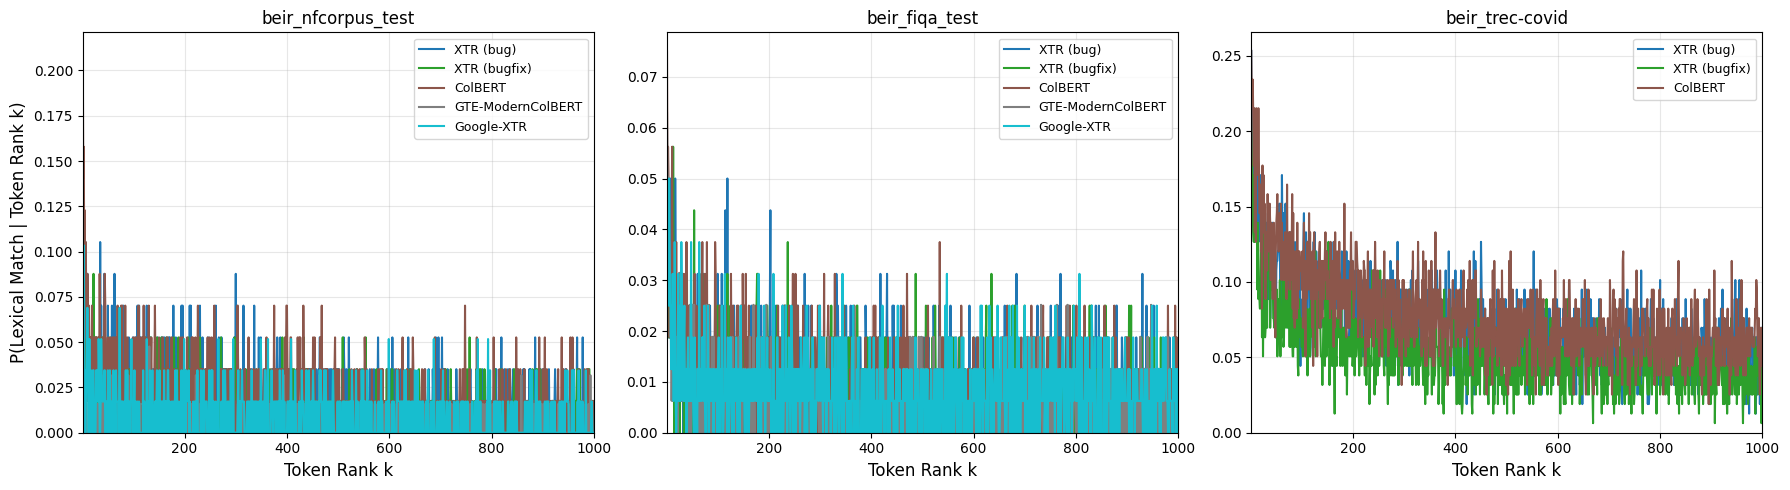

In [11]:
# Create subplots: one per dataset
num_datasets = len(DATASET_IDS)
fig, axes = plt.subplots(1, num_datasets, figsize=(6 * num_datasets, 5))

if num_datasets == 1:
    axes = [axes]

ranks = np.arange(1, MAX_RANK + 1)

# Color palette for models
colors = plt.cm.tab10(np.linspace(0, 1, len(MODELS)))

# Plot each dataset in its own subplot
for dataset_idx, dataset_id in enumerate(DATASET_IDS):
    ax = axes[dataset_idx]
    
    # Plot each model for this dataset
    for model_idx, (model_path, model_name) in enumerate(MODELS):
        if model_name in all_results.get(dataset_id, {}):
            p_lexical = all_results[dataset_id][model_name]["p_lexical"]
            
            ax.plot(ranks, p_lexical, linewidth=1.5, label=model_name, color=colors[model_idx])
    
    ax.set_xlabel("Token Rank k", fontsize=12)
    if dataset_idx == 0:
        ax.set_ylabel("P(Lexical Match | Token Rank k)", fontsize=12)
    ax.set_title(f"{sanitize_dataset_name(dataset_id)}", fontsize=12)
    ax.set_xlim(1, MAX_RANK)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## Breakdown: Lexical Match in Relevant vs Non-Relevant Docs

Does the lexical match rate differ for relevant vs non-relevant documents?

In [ ]:
# Build gold doc mask per query
def compute_lexical_match_by_relevance(
    query_embeddings: List[torch.Tensor],
    query_token_ids: List[torch.Tensor],
    query_ids: List[str],
    doc_embeddings_flat: torch.Tensor,
    doc_token_ids_flat: torch.Tensor,
    doc_indices: torch.Tensor,
    sampled_doc_ids: List[str],
    qrels: Dict[str, Dict[str, int]],
    relevance_threshold: int,
    max_rank: int,
    device: torch.device,
) -> Dict[str, Tuple[np.ndarray, np.ndarray, int]]:
    """
    Compute lexical match statistics split by document relevance.
    
    Returns dict with 'relevant' and 'non_relevant' keys, each containing:
        (lexical_counts, total_counts, total_query_tokens)
    """
    results = {
        "relevant": (np.zeros(max_rank, dtype=np.int64), np.zeros(max_rank, dtype=np.int64), 0),
        "non_relevant": (np.zeros(max_rank, dtype=np.int64), np.zeros(max_rank, dtype=np.int64), 0),
    }
    
    doc_emb = doc_embeddings_flat.to(device)
    doc_tids = doc_token_ids_flat.to(device)
    doc_idx_tensor = doc_indices.to(device)
    doc_emb_norm = torch.nn.functional.normalize(doc_emb, p=2, dim=1)
    
    for q_idx in tqdm(range(len(query_embeddings)), desc="Processing queries (by relevance)"):
        query_id = query_ids[q_idx]
        q_emb = query_embeddings[q_idx].to(device)
        q_tids = query_token_ids[q_idx].to(device)
        
        # Get relevant doc indices for this query
        query_qrels = qrels.get(query_id, {})
        relevant_doc_indices = set()
        for doc_id, rel in query_qrels.items():
            if rel >= relevance_threshold and doc_id in sampled_doc_ids:
                relevant_doc_indices.add(sampled_doc_ids.index(doc_id))
        
        q_emb_norm = torch.nn.functional.normalize(q_emb, p=2, dim=1)
        similarities = torch.mm(q_emb_norm, doc_emb_norm.t())
        
        # Ensure we don't exceed the number of query tokens
        num_query_tokens = min(q_emb.shape[0], q_tids.shape[0])
        
        for qt_idx in range(num_query_tokens):
            query_token_id = q_tids[qt_idx].item()
            _, top_indices = torch.topk(similarities[qt_idx], k=min(max_rank, len(doc_tids)))
            
            top_doc_token_ids = doc_tids[top_indices]
            top_doc_indices = doc_idx_tensor[top_indices]
            
            lexical_matches = (top_doc_token_ids == query_token_id).cpu().numpy()
            is_relevant = np.array([idx.item() in relevant_doc_indices for idx in top_doc_indices])
            
            for rank in range(len(lexical_matches)):
                key = "relevant" if is_relevant[rank] else "non_relevant"
                lc, tc, _ = results[key]
                lc[rank] += lexical_matches[rank]
                tc[rank] += 1
        
        # Update total tokens (same for both)
        results["relevant"] = (results["relevant"][0], results["relevant"][1], 
                               results["relevant"][2] + num_query_tokens)
        results["non_relevant"] = (results["non_relevant"][0], results["non_relevant"][1],
                                    results["non_relevant"][2] + num_query_tokens)
    
    return results

In [ ]:
# Run breakdown analysis
relevance_results = compute_lexical_match_by_relevance(
    query_embeddings=query_embeddings,
    query_token_ids=query_token_ids,
    query_ids=sampled_query_ids,
    doc_embeddings_flat=doc_token_embeddings_flat,
    doc_token_ids_flat=doc_token_ids_flat,
    doc_indices=doc_indices,
    sampled_doc_ids=sampled_doc_ids,
    qrels=qrels,
    relevance_threshold=RELEVANCE_THRESHOLD,
    max_rank=MAX_RANK,
    device=device,
)

# Compute probabilities
p_lexical_relevant = np.where(
    relevance_results["relevant"][1] > 0,
    relevance_results["relevant"][0] / relevance_results["relevant"][1],
    0.0
)
p_lexical_non_relevant = np.where(
    relevance_results["non_relevant"][1] > 0,
    relevance_results["non_relevant"][0] / relevance_results["non_relevant"][1],
    0.0
)

print(f"P(Lexical | rank 1, relevant): {p_lexical_relevant[0]:.4f}")
print(f"P(Lexical | rank 1, non-relevant): {p_lexical_non_relevant[0]:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ranks = np.arange(1, MAX_RANK + 1)

ax.plot(ranks, p_lexical, linewidth=2, label="All docs", color="black")
ax.plot(ranks, p_lexical_relevant, linewidth=1.5, label="Relevant docs", color="green", linestyle="--")
ax.plot(ranks, p_lexical_non_relevant, linewidth=1.5, label="Non-relevant docs", color="red", linestyle=":")

ax.set_xlabel("Rank k", fontsize=12)
ax.set_ylabel("P(Lexical Match | rank k)", fontsize=12)
ax.set_title(f"Lexical Match by Document Relevance\n{sanitize_model_name(MODEL_PATH)} on {DATASET_ID}", fontsize=12)
ax.set_xlim(1, MAX_RANK)
ax.set_ylim(0, 0.1)
ax.legend()
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Save Results

In [ ]:
import json
from datetime import datetime

results = {
    "model": MODEL_PATH,
    "dataset": DATASET_ID,
    "config": {
        "num_queries": len(sampled_query_ids),
        "num_docs": len(sampled_doc_ids),
        "num_relevant_docs": len(relevant_doc_ids),
        "num_negative_docs": len(sampled_negative_ids),
        "max_rank": MAX_RANK,
        "query_length": QUERY_LENGTH,
        "doc_length": DOC_LENGTH,
        "seed": SEED,
    },
    "total_query_tokens": total_query_tokens,
    "p_lexical": p_lexical.tolist(),
    "p_lexical_relevant": p_lexical_relevant.tolist(),
    "p_lexical_non_relevant": p_lexical_non_relevant.tolist(),
    "lexical_counts": lexical_counts.tolist(),
    "total_counts": total_counts.tolist(),
    "timestamp": datetime.now().isoformat(),
}

# Save to results directory
output_dir = Path("results/lexical_match_analysis") / sanitize_dataset_name(DATASET_ID) / sanitize_model_name(MODEL_PATH)
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "lexical_match_data.json"
with open(output_file, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to: {output_file}")

## Summary Statistics

In [ ]:
print("=" * 60)
print("EXPERIMENT 5: P(Lexical Match | Token Rank) Summary")
print("=" * 60)
print(f"Model: {MODEL_PATH}")
print(f"Dataset: {DATASET_ID}")
print(f"Queries: {len(sampled_query_ids)}, Docs: {len(sampled_doc_ids)}")
print(f"Total query tokens: {total_query_tokens}")
print()
print("P(Lexical Match | rank k):")
print(f"  Rank 1:    {p_lexical[0]:.4f}")
print(f"  Rank 10:   {p_lexical[9]:.4f}")
print(f"  Rank 50:   {p_lexical[49]:.4f}")
print(f"  Rank 100:  {p_lexical[99]:.4f}")
print(f"  Rank 500:  {p_lexical[499]:.4f}" if MAX_RANK >= 500 else "")
print()
print("By document relevance (rank 1):")
print(f"  Relevant docs:     {p_lexical_relevant[0]:.4f}")
print(f"  Non-relevant docs: {p_lexical_non_relevant[0]:.4f}")